In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('cmi_clean.csv')

In [4]:
df.shape


(8460, 32)

In [5]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured',
       'FGC_Muscular_Endurance', 'Social_Digital_Displacement',
       'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count',
       'ScreenTime_Age_Ratio', 'ScreenTime_Category'],
      dtype='object')

First, let's identify which columns are binary (contain only 0 and 1 values).

In [6]:
binary_columns = []
for col in df.columns:
    unique_values = df[col].dropna().unique()
    if len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
        binary_columns.append(col)

print(f"Identified binary columns: {binary_columns}")

Identified binary columns: ['Basic_Demos-Sex', 'SDS_measured', 'BIA_measured']


In [7]:
print(f"DataFrame shape before dropping binary columns: {df.shape}")

if binary_columns:
    df = df.drop(columns=binary_columns)
    print(f"DataFrame shape after dropping binary columns: {df.shape}")
else:
    print("No binary columns found to drop.")

DataFrame shape before dropping binary columns: (8460, 32)
DataFrame shape after dropping binary columns: (8460, 29)


Next, let's check for missing values in the DataFrame.

In [8]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with missing values and their counts:")
print(missing_values)

Columns with missing values and their counts:
Series([], dtype: int64)


Now, let's remove the 'sii' column from the DataFrame as it is specified as the target variable.

In [9]:
if 'sii' in df.columns:
    df = df.drop(columns=['sii'])
    print("'sii' column dropped successfully.")
else:
    print("'sii' column not found in the DataFrame.")

print("Current DataFrame columns:")
print(df.columns)

'sii' column dropped successfully.
Current DataFrame columns:
Index(['Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height',
       'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'FGC_Muscular_Endurance',
       'Social_Digital_Displacement', 'Lifestyle_Risk_Score',
       'Metabolic_Alarms_Count', 'ScreenTime_Age_Ratio',
       'ScreenTime_Category'],
      dtype='object')


Now, let's remove the other derivated column from the DataFrame.

In [10]:
"""if 'ScreenTime_Category' in df.columns:
    df = df.drop(columns=['ScreenTime_Category'])
    print("'ScreenTime_Category' column dropped successfully.")
else:
    print("'ScreenTime_Category' column not found in the DataFrame.")

print("Current DataFrame columns after attempting to drop 'ScreenTime_Category':")
print(df.columns)"""

'if \'ScreenTime_Category\' in df.columns:\n    df = df.drop(columns=[\'ScreenTime_Category\'])\n    print("\'ScreenTime_Category\' column dropped successfully.")\nelse:\n    print("\'ScreenTime_Category\' column not found in the DataFrame.")\n\nprint("Current DataFrame columns after attempting to drop \'ScreenTime_Category\':")\nprint(df.columns)'

In [11]:
features_to_drop = [
    'ScreenTime_Category'
]

for col in features_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"'{col}' column dropped successfully.")
    else:
        print(f"'{col}' column not found in the DataFrame.")

print("\nFinal DataFrame columns for Anomaly Detection:")
print(df.columns)

'ScreenTime_Category' column dropped successfully.

Final DataFrame columns for Anomaly Detection:
Index(['Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height',
       'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'FGC_Muscular_Endurance',
       'Social_Digital_Displacement', 'Lifestyle_Risk_Score',
       'Metabolic_Alarms_Count', 'ScreenTime_Age_Ratio'],
      dtype='object')


In [12]:
df.shape

(8460, 27)

Now, let's perform feature scaling on the numerical columns. This is important for many machine learning algorithms, especially those that rely on distance metrics, to ensure that all features contribute equally to the model.

In [13]:
"""scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("DataFrame after feature scaling (first 5 rows):")
print(df_scaled.head())"""

'scaler = StandardScaler()\ndf_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)\n\nprint("DataFrame after feature scaling (first 5 rows):")\nprint(df_scaled.head())'

In [14]:
df.shape

(8460, 27)

Thresholds (99th percentile) for different k:
k=5: 6.1311
k=10: 6.5994
k=20: 6.9532
k=30: 7.2463
k=50: 7.5200


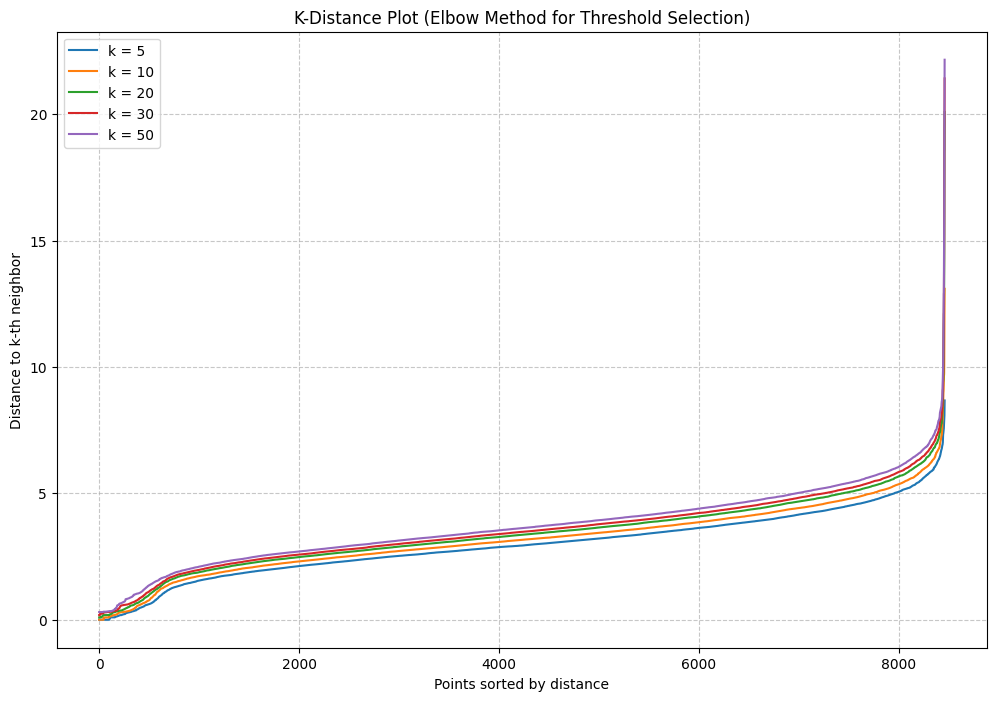

In [15]:
# Select all numerical columns (the 27 remains variables)
X = df.select_dtypes(include=[np.number])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define a range of k values to test
k_values = [5, 10, 20, 30, 50]
plt.figure(figsize=(12, 8))

for k in k_values:
    # Fit NearestNeighbors
    # We use n_neighbors=k+1 because the first neighbor is the point itself (distance 0)
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)

    # Sort the distances to the k-th neighbor
    # distances[:, k-1] gives the distance to the k-th nearest neighbor
    k_dist = np.sort(distances[:, k-1])

    # Plot
    plt.plot(k_dist, label=f'k = {k}')

plt.title('K-Distance Plot (Elbow Method for Threshold Selection)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to k-th neighbor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('knn_multik_elbow.png')

# Output some summary statistics for the 99th percentile (Top 1%) for each k
print("Thresholds (99th percentile) for different k:")
for k in k_values:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)
    thresh = np.percentile(distances[:, k-1], 99)
    print(f"k={k}: {thresh:.4f}")

In [16]:
X = df.select_dtypes(include=[np.number])

# 2. Scaling (Fondamentale: mette tutte le 32 variabili sullo stesso piano)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# 3. Implementazione k-NN
k = 30
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X_scaled)

# Calcoliamo le distanze dal k-esimo vicino (usiamo l'indice k-1)
distances, indices = nbrs.kneighbors(X_scaled)
knn_distances = distances[:, k-1]

# Aggiungiamo lo score al dataset
df['knn_anomaly_score'] = knn_distances

# 4. Identificazione Top 1% (85 outlier circa)
threshold = np.percentile(knn_distances, 99)
df['is_outlier'] = df['knn_anomaly_score'] > threshold

print(f"Soglia (Distanza dal 20° vicino): {threshold:.4f}")
print(f"Numero di outlier identificati: {df['is_outlier'].sum()}")

Soglia (Distanza dal 20° vicino): 7.2463
Numero di outlier identificati: 85


In [17]:
# 2. Definizione delle variabili
features = [
    'Basic_Demos-Age',  'CGAS-CGAS_Score', 'Physical-BMI',
    'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
    'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
    'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_FFM',
    'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
    'BIA-BIA_SMM', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday',
    'FGC_Flexibility_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'FGC_Muscular_Endurance',
    'Social_Digital_Displacement' , 'Lifestyle_Risk_Score', 'ScreenTime_Age_Ratio',
    'Metabolic_Alarms_Count'

]

# 3. Scaling e k-NN (k=20)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df[features])

k = 30
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
df['knn_dist_20'] = distances[:, k-1]

# 4. Identificazione Top 1% Outlier
threshold = np.percentile(df['knn_dist_20'], 99)
df['is_outlier'] = df['knn_dist_20'] > threshold

# 5. Calcolo statistiche per TUTTE le colonne
# Calcoliamo medie e differenze
stats = []
for col in features:
    outlier_mean = df.loc[df['is_outlier'] == True, col].mean()
    inlier_mean = df.loc[df['is_outlier'] == False, col].mean()
    diff = outlier_mean - inlier_mean
    # Differenza percentuale (con protezione per divisione per zero)
    diff_pct = (diff / (inlier_mean + 1e-6)) * 100

    stats.append({
        'Variable': col,
        'Outlier Mean': outlier_mean,
        'Inlier Mean': inlier_mean,
        'Difference': diff,
        '% Difference': diff_pct
    })

comparison_df = pd.DataFrame(stats)

# Visualizziamo i risultati ordinati per differenza assoluta
print(comparison_df.sort_values(by='Difference', ascending=False).to_string(index=False))

# Salvataggio per l'utente
comparison_df.to_csv('confronto_completo_outlier.csv', index=False)

                              Variable  Outlier Mean  Inlier Mean  Difference  % Difference
                       Physical-Weight    154.502824    83.830664   70.672160     84.303471
                           BIA-BIA_FFM     87.789196    64.236950   23.552246     36.664639
                  Physical-Systolic_BP    132.685882   115.410473   17.275409     14.968667
                          FGC_Grip_Avg     35.557647    20.153851   15.403796     76.431029
                           BIA-BIA_SMM     44.977409    30.548981   14.428428     47.230470
                 Physical-Diastolic_BP     79.437647    68.751328   10.686319     15.543436
                          Physical-BMI     28.643140    19.331475    9.311664     48.168407
                FGC_Muscular_Endurance     14.441176     6.948179    7.492997    107.841151
                           BIA-BIA_Fat     25.649356    18.929024    6.720333     35.502794
                       Physical-Height     65.000471    58.343566    6.656905   

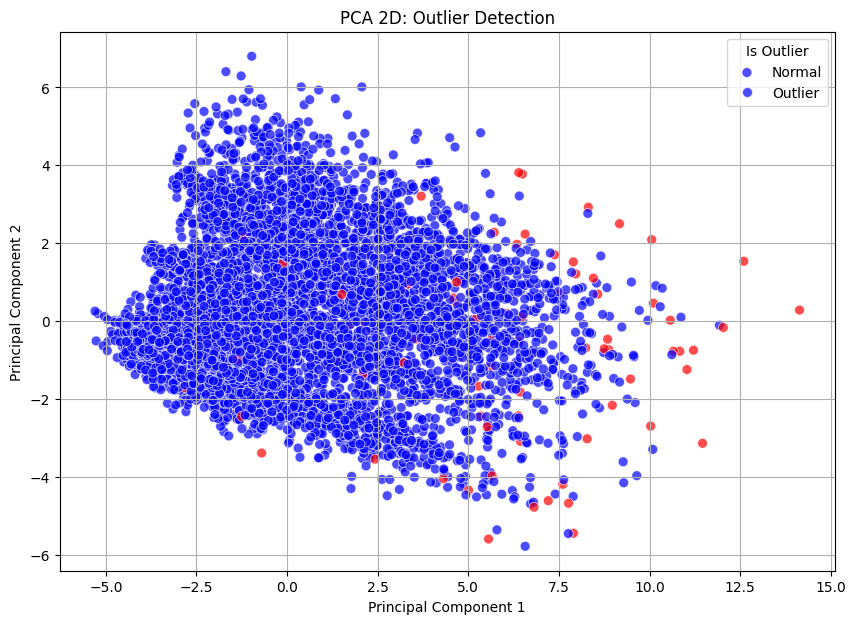

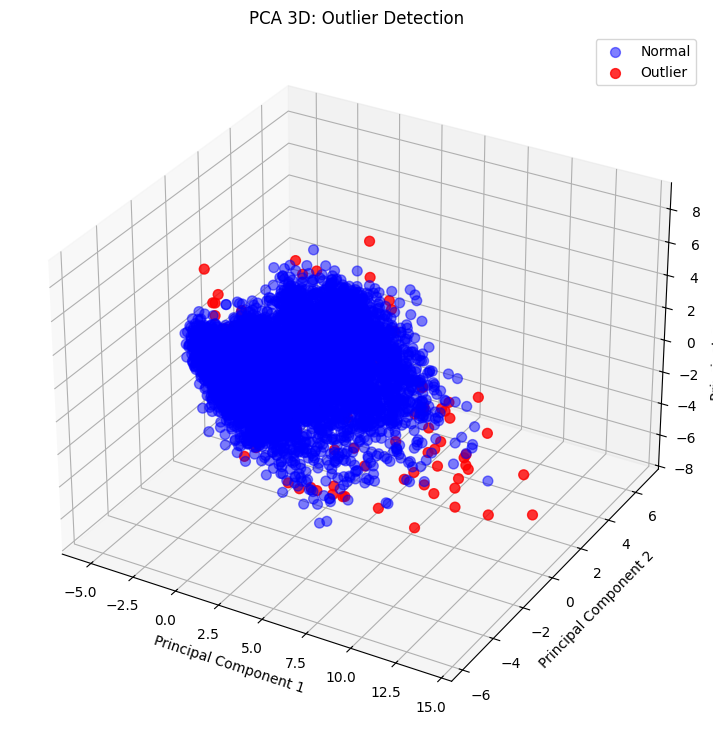

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_scaled is available, if not, re-scale
#if 'X_scaled' not in globals():
    # Select all numerical columns (the 32 variables)
features = [
    'Basic_Demos-Age',  'CGAS-CGAS_Score', 'Physical-BMI',
    'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
    'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
    'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_FFM',
    'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
    'BIA-BIA_SMM', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday',
    'FGC_Flexibility_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'FGC_Muscular_Endurance',
    'Social_Digital_Displacement' , 'Lifestyle_Risk_Score', 'ScreenTime_Age_Ratio'

]
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(df[features])

# 1. PCA (Principal Component Analysis)

# PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=df['is_outlier'],
    palette={True: 'red', False: 'blue'},
    alpha=0.7,
    s=50 # Increased point size for better visibility
)
plt.title('PCA 2D: Outlier Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Is Outlier', labels=['Normal', 'Outlier'])
plt.grid(True)
plt.show()

# PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Separate outliers for different color
outliers_pca_3d = X_pca_3d[df['is_outlier']]
normal_pca_3d = X_pca_3d[~df['is_outlier']]

ax.scatter(normal_pca_3d[:, 0], normal_pca_3d[:, 1], normal_pca_3d[:, 2], c='blue', label='Normal', alpha=0.5, s=50)
ax.scatter(outliers_pca_3d[:, 0], outliers_pca_3d[:, 1], outliers_pca_3d[:, 2], c='red', label='Outlier', alpha=0.8, s=50)

ax.set_title('PCA 3D: Outlier Detection')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend()
plt.show()

In [19]:
# Get the top outlier row
top_outlier_row = df.sort_values(by='knn_anomaly_score', ascending=False).head(1)

print("Top Outlier Row based on k-NN Anomaly Score:")
print(top_outlier_row)

Top Outlier Row based on k-NN Anomaly Score:
      Basic_Demos-Age  CGAS-CGAS_Score  Physical-BMI  Physical-Height  \
3767                8             60.0     16.811457             51.0   

      Physical-Weight  Physical-Waist_Circumference  Physical-Diastolic_BP  \
3767             62.2                          25.4                   61.0   

      Physical-HeartRate  Physical-Systolic_BP  Fitness_Endurance-Max_Stage  \
3767                80.0                 109.0                         28.0   

      ...  FGC_Grip_Avg  PAQ_Total  FGC_Muscular_Endurance  \
3767  ...        20.625       3.02                    20.0   

      Social_Digital_Displacement  Lifestyle_Risk_Score  \
3767                          0.0              0.788756   

      Metabolic_Alarms_Count  ScreenTime_Age_Ratio  knn_anomaly_score  \
3767                       0                   0.0          21.422201   

      is_outlier  knn_dist_20  
3767        True    21.422201  

[1 rows x 30 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


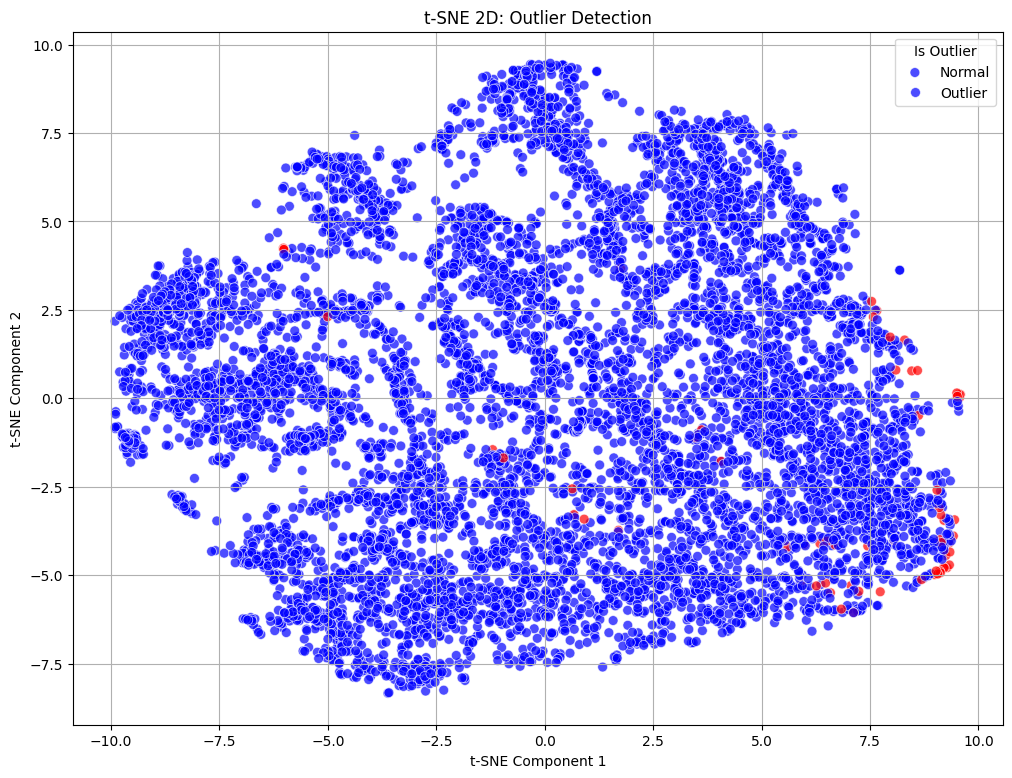

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_scaled is available. It was created in a previous step.
# If not, you might need to re-run the scaling step.
if 'X_scaled' not in globals():
    # Select all numerical columns (the 27 variables after cleaning)
    # We need to re-create the 'features' list based on the current df columns
    features = df.columns.tolist()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

# 2. t-SNE (t-Distributed Stochastic Neighbor Embedding) 2D
# t-SNE is computationally more intensive than PCA, especially for large datasets.
# Perplexity is a crucial parameter, usually between 5 and 50.
# n_iter specifies the number of iterations. More iterations mean more time but better results.
# random_state for reproducibility.

tsne_2d = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 9))
sns.scatterplot(
    x=X_tsne_2d[:, 0],
    y=X_tsne_2d[:, 1],
    hue=df['is_outlier'], # Assuming 'is_outlier' column exists from k-NN analysis
    palette={True: 'red', False: 'blue'},
    alpha=0.7,
    s=50
)
plt.title('t-SNE 2D: Outlier Detection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Is Outlier', labels=['Normal', 'Outlier'])
plt.grid(True)
plt.show()

In [21]:
# Filter the DataFrame to get only the outlier rows
outliers_df = df[df['is_outlier'] == True]

print("Identified Outlier Rows:")
print(outliers_df)

# Optional: Save the outlier rows to a CSV file
outliers_df.to_csv('identified_outliers.csv', index=False)
print("\nOutlier rows also saved to 'identified_outliers.csv'")

Identified Outlier Rows:
      Basic_Demos-Age  CGAS-CGAS_Score  Physical-BMI  Physical-Height  \
59                 17             65.0     24.446886            68.00   
87                 17             65.0     26.630764            77.00   
306                16             65.0     46.102914            67.50   
356                12             65.0     25.291361            65.00   
436                19             39.0     27.257677            69.00   
...               ...              ...           ...              ...   
7438                9             70.5     14.771751            63.36   
7694               11             80.5     21.722149            65.46   
7704               10             82.5     18.506154            54.22   
7884               10             45.5     27.856988            64.16   
8300               16             71.0     20.219875            70.33   

      Physical-Weight  Physical-Waist_Circumference  Physical-Diastolic_BP  \
59             160.8

In [22]:
# Get the top outlier row from the identified outliers
top_outlier_row = outliers_df.sort_values(by='knn_anomaly_score', ascending=False).head(1)

print("Top Outlier Row based on k-NN Anomaly Score (from identified outliers):")
print(top_outlier_row)

Top Outlier Row based on k-NN Anomaly Score (from identified outliers):
      Basic_Demos-Age  CGAS-CGAS_Score  Physical-BMI  Physical-Height  \
3767                8             60.0     16.811457             51.0   

      Physical-Weight  Physical-Waist_Circumference  Physical-Diastolic_BP  \
3767             62.2                          25.4                   61.0   

      Physical-HeartRate  Physical-Systolic_BP  Fitness_Endurance-Max_Stage  \
3767                80.0                 109.0                         28.0   

      ...  FGC_Grip_Avg  PAQ_Total  FGC_Muscular_Endurance  \
3767  ...        20.625       3.02                    20.0   

      Social_Digital_Displacement  Lifestyle_Risk_Score  \
3767                          0.0              0.788756   

      Metabolic_Alarms_Count  ScreenTime_Age_Ratio  knn_anomaly_score  \
3767                       0                   0.0          21.422201   

      is_outlier  knn_dist_20  
3767        True    21.422201  

[1 rows x

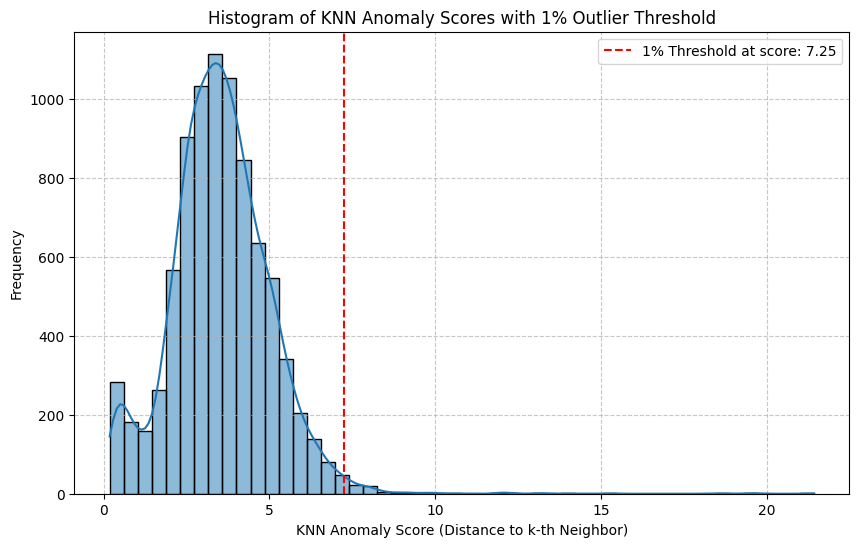

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['knn_anomaly_score'], bins=50, kde=True)
plt.axvline(x=threshold, color='red', linestyle='--', label=f'1% Threshold at score: {threshold:.2f}')
plt.title('Histogram of KNN Anomaly Scores with 1% Outlier Threshold')
plt.xlabel('KNN Anomaly Score (Distance to k-th Neighbor)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The value of 7.25 for the threshold comes from calculating the 99th percentile of the knn_anomaly_score for k=20. This means that only 1% of the data points have an anomaly score higher than 7.25, and these are the points we are identifying as outliers. This is a common method to define a strict outlier group, focusing on the most extreme cases.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


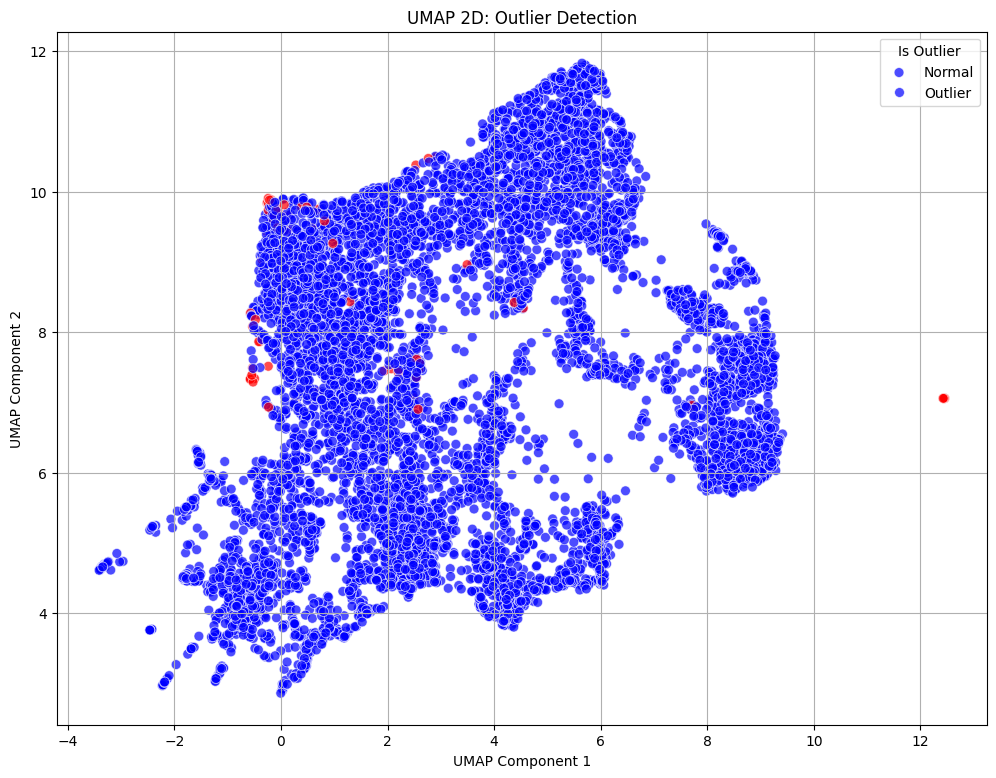

In [24]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_scaled is available. It was created in a previous step.
# If not, you might need to re-run the scaling step.
# For UMAP, it's often recommended to scale data first.

# Initialize UMAP
# n_components: number of dimensions for the reduced space (e.g., 2 for 2D visualization)
# n_neighbors: controls how UMAP balances local versus global structure in data (typically 5 to 50)
# min_dist: controls how tightly clustered points are in the low-dimensional representation (typically 0.0 to 0.99)
# random_state for reproducibility
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(12, 9))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=df['is_outlier'], # Assuming 'is_outlier' column exists from k-NN analysis
    palette={True: 'red', False: 'blue'},
    alpha=0.7,
    s=50
)
plt.title('UMAP 2D: Outlier Detection')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(title='Is Outlier', labels=['Normal', 'Outlier'])
plt.grid(True)
plt.show()

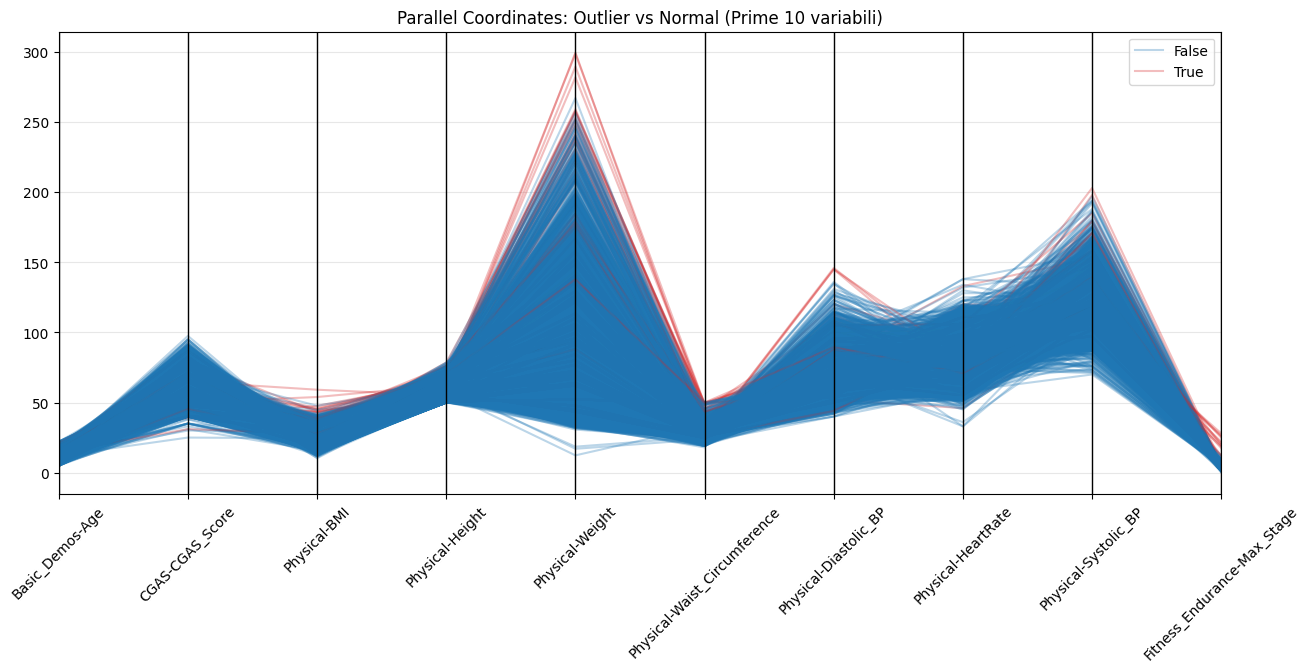

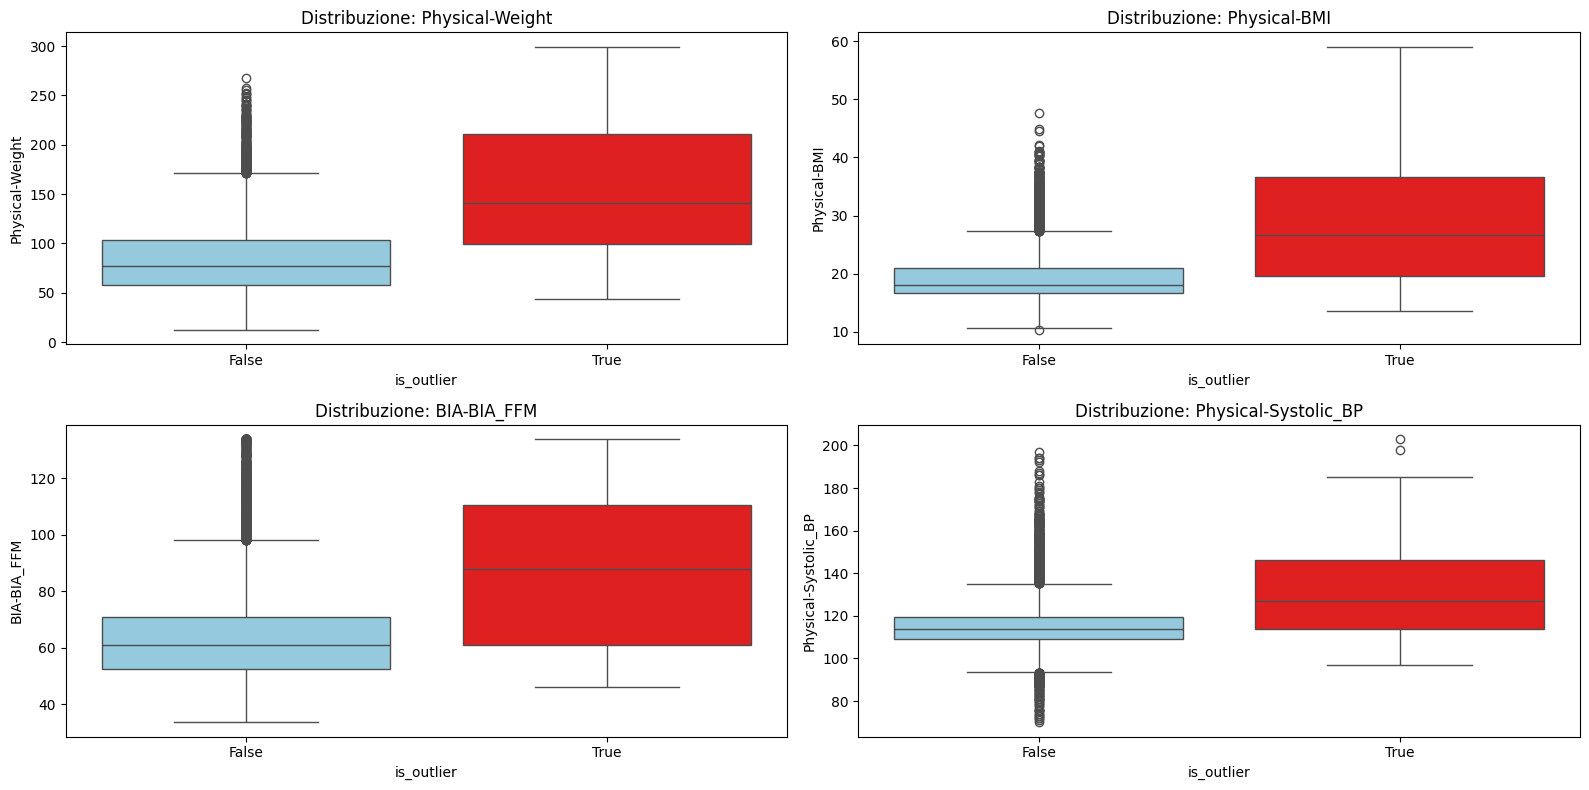

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Parallel Coordinates Plot (Prime 10 variabili)
plt.figure(figsize=(15, 6))
cols_to_show = features[:10] + ['is_outlier']
# Convertiamo is_outlier in stringa per evitare problemi di mapping colori
df_plot = df.copy()
df_plot['is_outlier'] = df_plot['is_outlier'].astype(str)

pd.plotting.parallel_coordinates(df_plot[cols_to_show], 'is_outlier', color=['#1f77b4', '#d62728'], alpha=0.3)
plt.title('Parallel Coordinates: Outlier vs Normal (Prime 10 variabili)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# 2. Boxplot Comparativo delle variabili chiave
key_features = ['Physical-Weight', 'Physical-BMI', 'BIA-BIA_FFM', 'Physical-Systolic_BP']
plt.figure(figsize=(16, 8))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_outlier', y=col, hue='is_outlier', data=df_plot, palette={'True': 'red', 'False': 'skyblue'}, legend=False)
    plt.title(f'Distribuzione: {col}')

plt.tight_layout()
plt.show()

=== OVERLAP ===
KNN flags:       85
HBOS flags:      85
BOTH flag:       39
KNN only:        46
HBOS only:       46

=== CONSENSUS OUTLIER PROFILE ===
                               Feature  Consensus Outlier Mean  Normal Children Mean  Difference  % Difference
                       Physical-Weight                  157.28                 84.20       73.08          86.8
                           BIA-BIA_FFM                   88.67                 64.36       24.31          37.8
                          FGC_Grip_Avg                   38.90                 20.22       18.68          92.4
                  Physical-Systolic_BP                  130.43                115.52       14.92          12.9
                           BIA-BIA_SMM                   45.21                 30.63       14.58          47.6
                          Physical-BMI                   29.48                 19.38       10.10          52.1
                 Physical-Diastolic_BP                   78.22          

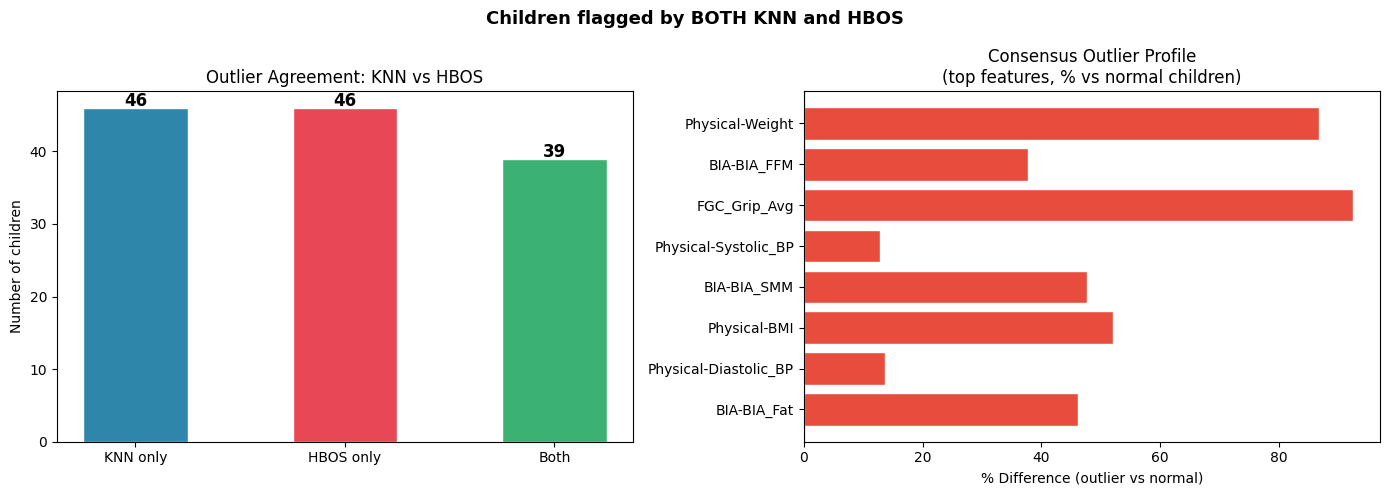

In [26]:
# ── What children profile do BOTH methods agree on? ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load HBOS labels (produced by hbos2.ipynb)
hbos = pd.read_csv("hbos_labels.csv", index_col=0)

# Attach HBOS label to current df (aligned by row position)
df["hbos_outlier"] = hbos["HBOS_PCA_label"].values
df["knn_outlier"]  = df["is_outlier"].astype(int)

# Consensus = flagged by BOTH
df["consensus_outlier"] = (df["knn_outlier"] == 1) & (df["hbos_outlier"] == 1)

print("=== OVERLAP ===")
print(f"KNN flags:       {df['knn_outlier'].sum()}")
print(f"HBOS flags:      {df['hbos_outlier'].sum()}")
print(f"BOTH flag:       {df['consensus_outlier'].sum()}")
print(f"KNN only:        {((df['knn_outlier']==1) & (df['hbos_outlier']==0)).sum()}")
print(f"HBOS only:       {((df['hbos_outlier']==1) & (df['knn_outlier']==0)).sum()}")

# ── Profile: compare consensus outliers vs normal children ────────────────────
features_compare = [
    'Basic_Demos-Age', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate',
    'Physical-Systolic_BP', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI',
    'BIA-BIA_Fat', 'BIA-BIA_SMM', 'FGC_Grip_Avg', 'FGC_Muscular_Endurance',
    'FGC_Flexibility_Avg', 'PAQ_Total', 'Fitness_Endurance-Max_Stage',
    'Metabolic_Alarms_Count', 'Lifestyle_Risk_Score', 'CGAS-CGAS_Score',
    'PreInt_EduHx-computerinternet_hoursday'
]
features_compare = [f for f in features_compare if f in df.columns]

stats = []
for col in features_compare:
    o_mean = df.loc[df["consensus_outlier"], col].mean()
    i_mean = df.loc[~df["consensus_outlier"], col].mean()
    diff   = o_mean - i_mean
    pct    = (diff / (abs(i_mean) + 1e-6)) * 100
    stats.append({"Feature": col,
                  "Consensus Outlier Mean": round(o_mean, 2),
                  "Normal Children Mean":   round(i_mean, 2),
                  "Difference":             round(diff, 2),
                  "% Difference":           round(pct, 1)})

profile = pd.DataFrame(stats).sort_values("Difference", ascending=False)
print("\n=== CONSENSUS OUTLIER PROFILE ===")
print(profile.to_string(index=False))
profile.to_csv("consensus_profile.csv", index=False)

# ── Bar chart: who flags what ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlap counts
labels = ["KNN only", "HBOS only", "Both"]
sizes  = [
    ((df["knn_outlier"]==1) & (df["hbos_outlier"]==0)).sum(),
    ((df["hbos_outlier"]==1) & (df["knn_outlier"]==0)).sum(),
    df["consensus_outlier"].sum()
]
bars = axes[0].bar(labels, sizes, color=["#2E86AB","#E84855","#3BB273"], edgecolor="white", width=0.5)
for bar, n in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(n), ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of children")
axes[0].set_title("Outlier Agreement: KNN vs HBOS")

# Right: top 8 features by difference for consensus outliers
top8 = profile.head(8)
colors = ["#E74C3C" if d > 0 else "#3498DB" for d in top8["Difference"]]
axes[1].barh(top8["Feature"], top8["% Difference"], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("% Difference (outlier vs normal)")
axes[1].set_title("Consensus Outlier Profile\n(top features, % vs normal children)")
axes[1].invert_yaxis()

plt.suptitle("Children flagged by BOTH KNN and HBOS", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("consensus_outlier_profile.png", dpi=150, bbox_inches="tight")
plt.show()

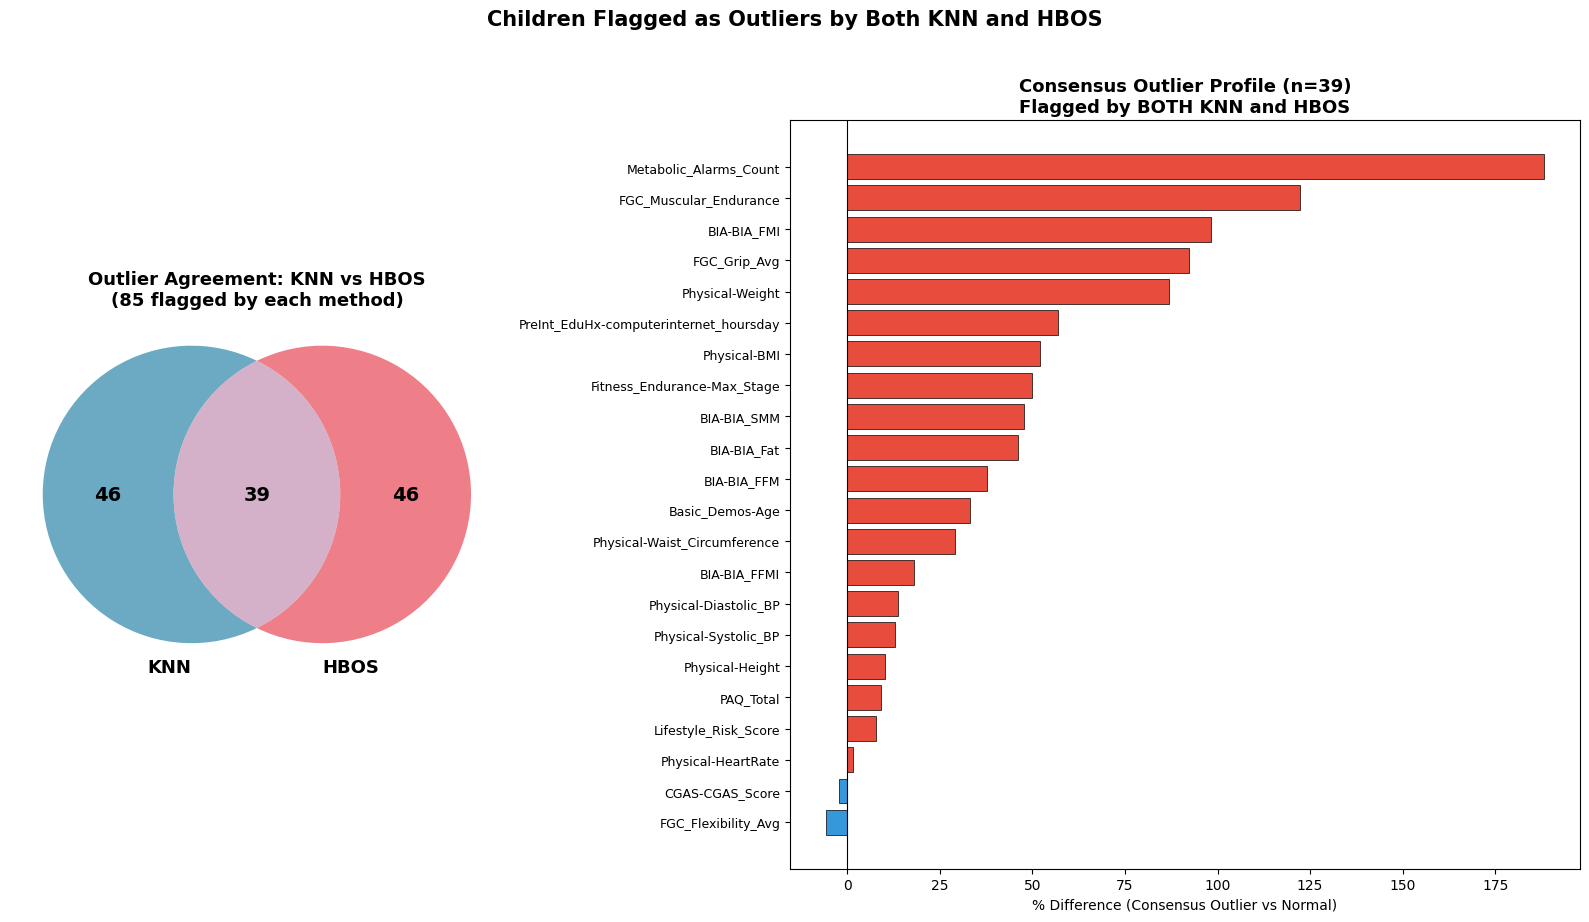

In [1]:
# pip install matplotlib-venn   (run once if not installed)
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios': [1, 1.6]})

# ── Left: Venn diagram of KNN vs HBOS overlap ──────────────────────────────
ax_venn = axes[0]
v = venn2(subsets=(46, 46, 39), set_labels=('KNN', 'HBOS'), ax=ax_venn,
          set_colors=('#2E86AB', '#E84855'), alpha=0.7)
for text in v.subset_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')
for text in v.set_labels:
    text.set_fontsize(13)
    text.set_fontweight('bold')
ax_venn.set_title("Outlier Agreement: KNN vs HBOS\n(85 flagged by each method)",
                   fontsize=13, fontweight='bold')

# ── Right: Consensus outlier profile, all 21 features ──────────────────────
ax_bar = axes[1]

data = [
    ("Metabolic_Alarms_Count", 188.2),
    ("FGC_Muscular_Endurance", 122.3),
    ("BIA-BIA_FMI", 98.1),
    ("FGC_Grip_Avg", 92.4),
    ("Physical-Weight", 86.8),
    ("PreInt_EduHx-computerinternet_hoursday", 57.0),
    ("Physical-BMI", 52.1),
    ("Fitness_Endurance-Max_Stage", 49.9),
    ("BIA-BIA_Fat", 46.2),
    ("BIA-BIA_SMM", 47.6),
    ("Basic_Demos-Age", 33.2),
    ("Physical-Waist_Circumference", 29.1),
    ("BIA-BIA_FFM", 37.8),
    ("BIA-BIA_FFMI", 18.0),
    ("Physical-Diastolic_BP", 13.7),
    ("Physical-Systolic_BP", 12.9),
    ("Physical-Height", 10.2),
    ("PAQ_Total", 9.1),
    ("Lifestyle_Risk_Score", 7.8),
    ("Physical-HeartRate", 1.5),
    ("FGC_Flexibility_Avg", -5.8),
    ("CGAS-CGAS_Score", -2.3),
]
data.sort(key=lambda x: x[1])
labels = [d[0] for d in data]
values = [d[1] for d in data]
colors = ['#3498DB' if v < 0 else '#E74C3C' for v in values]

ax_bar.barh(labels, values, color=colors, edgecolor='black', linewidth=0.5)
ax_bar.axvline(0, color='black', linewidth=0.8)
ax_bar.set_xlabel("% Difference (Consensus Outlier vs Normal)")
ax_bar.set_title("Consensus Outlier Profile (n=39)\nFlagged by BOTH KNN and HBOS",
                  fontsize=13, fontweight='bold')
ax_bar.tick_params(axis='y', labelsize=9)

plt.suptitle("Children Flagged as Outliers by Both KNN and HBOS",
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("consensus_combined.png", dpi=150, bbox_inches='tight')
plt.show()